# Other Plotting libraries

### Seaborn

Seaborn is a library for making statistical graphics in Python. It is built on top of matplotlib and closely integrated with pandas data structures.

Here is some of the functionality that seaborn offers:

1. A dataset-oriented API for examining relationships between multiple variables

2. Specialized support for using categorical variables to show observations or aggregate statistics

3. Options for visualizing univariate or bivariate distributions and for comparing them between subsets of data

4. Automatic estimation and plotting of linear regression models for different kinds dependent variables

5. Convenient views onto the overall structure of complex datasets

6. High-level abstractions for structuring multi-plot grids that let you easily build complex visualizations

7. Concise control over matplotlib figure styling with several built-in themes

8. Tools for choosing color palettes that faithfully reveal patterns in your data

Seaborn aims to make visualization a central part of exploring and understanding data. Its dataset-oriented plotting functions operate on dataframes and arrays containing whole datasets and internally perform the necessary semantic mapping and statistical aggregation to produce informative plots.

*Source:*https://seaborn.pydata.org/introduction.html

### Plotly
The plotly Python library is an interactive, open-source plotting library that supports over 40 unique chart types covering a wide range of statistical, financial, geographic, scientific, and 3-dimensional use-cases.

Built on top of the Plotly JavaScript library (plotly.js), plotly enables Python users to create beautiful interactive web-based visualizations that can be displayed in Jupyter notebooks, saved to standalone HTML files, or served as part of pure Python-built web applications using Dash. 

Has two interfaces: **plotly express** and **plotly graph objects**. Express version let's us to create beautiful and interactive graphs without much hassle but we will not have much flexibility on how the graphs look. Graph objects will give us more flexibility but requires a lot of coding. We will use Express version in this course. 



### Installing Plotly for Anaconda

Run the following command from anaconda command line: 

**Install Plotly:** ``` conda install -c plotly plotly```

### Example Datasets

Plotly express inlcudes many of the famous datasets. You can directly import it into your code as a pandas dataframe. Complete list of example datasets can be found here: http://plotly.github.io/datasets/

Let's import Gapminder dataset: 

In [1]:
!conda install -c plotly plotly

Channels:
 - plotly
 - defaults
 - conda-forge
Platform: win-64
Solving environment: ...working... done

# All requested packages already installed.



In [1]:
import plotly.express as px
df = px.data.gapminder()

df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


### Querying data


In [2]:
df_Turkey = df.query("country=='Turkey'")

df_Turkey

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
1572,Turkey,Europe,1952,43.585,22235677,1969.100980,TUR,792
1573,Turkey,Europe,1957,48.079,25670939,2218.754257,TUR,792
1574,Turkey,Europe,1962,52.098,29788695,2322.869908,TUR,792
1575,Turkey,Europe,1967,54.336,33411317,2826.356387,TUR,792
1576,Turkey,Europe,1972,57.005,37492953,3450.696380,TUR,792
1577,Turkey,Europe,1977,59.507,42404033,4269.122326,TUR,792
1578,Turkey,Europe,1982,61.036,47328791,4241.356344,TUR,792
1579,Turkey,Europe,1987,63.108,52881328,5089.043686,TUR,792
1580,Turkey,Europe,1992,66.146,58179144,5678.348271,TUR,792
1581,Turkey,Europe,1997,68.835,63047647,6601.429915,TUR,792


### Create a line chart

**Documentation:** https://plotly.com/python-api-reference/generated/plotly.express.line.html#plotly.express.line

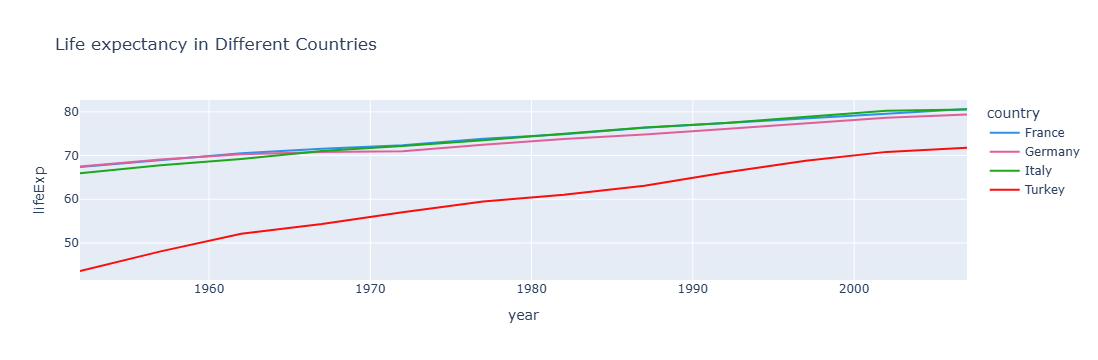

In [7]:
import numpy as np
df_Europe = df.query("country=='Turkey' | country=='Germany' | country=='France' | country=='Italy'")

px.line(data_frame=df_Europe, x="year", y='lifeExp', color='country',
             title='Life expectancy in Different Countries', color_discrete_sequence=px.colors.qualitative.Dark24,
             hover_name="country")

In [10]:
df_Europe.tail()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
1579,Turkey,Europe,1987,63.108,52881328,5089.043686,TUR,792
1580,Turkey,Europe,1992,66.146,58179144,5678.348271,TUR,792
1581,Turkey,Europe,1997,68.835,63047647,6601.429915,TUR,792
1582,Turkey,Europe,2002,70.845,67308928,6508.085718,TUR,792
1583,Turkey,Europe,2007,71.777,71158647,8458.276384,TUR,792


### Create a Scatter Plot

**Documentation:** https://plotly.com/python-api-reference/generated/plotly.express.scatter.html

In [9]:
df_2007 = df.query("year== 2007")
df_2007.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32


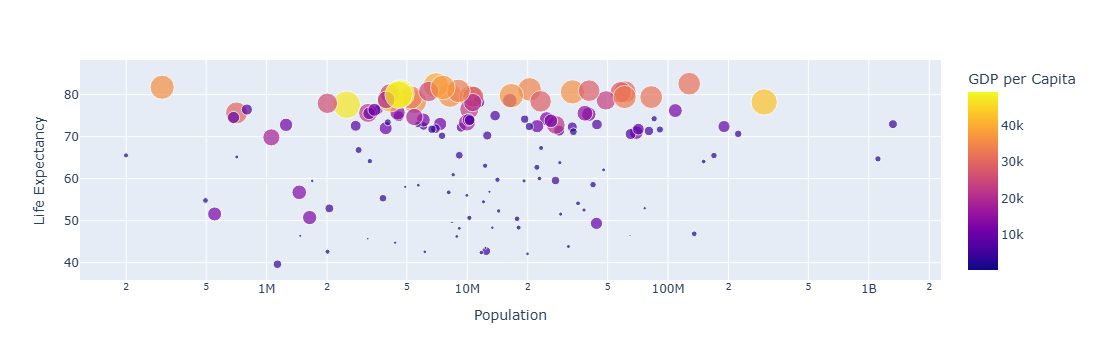

In [12]:
px.scatter(df_2007, x= "pop", log_x = True, y="lifeExp",  size="gdpPercap", color="gdpPercap", hover_name="country",
          labels = {"lifeExp": "Life Expectancy", "pop": "Population", "gdpPercap": "GDP per Capita"})
# labels = {"lifeExp": "Life Expectancy", "pop": "Population", "gdpPercap": "GDP per Capita"}


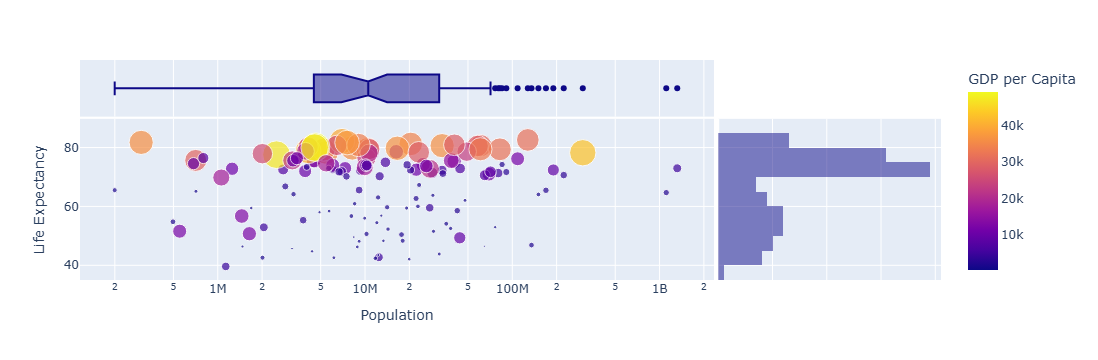

In [13]:
px.scatter(df_2007, x= "pop", y="lifeExp", log_x=True, hover_name="country",
           size="gdpPercap", color = "gdpPercap",labels = {"lifeExp": "Life Expectancy", "pop": "Population", "gdpPercap": "GDP per Capita"},
           marginal_x ="box", marginal_y="histogram" )

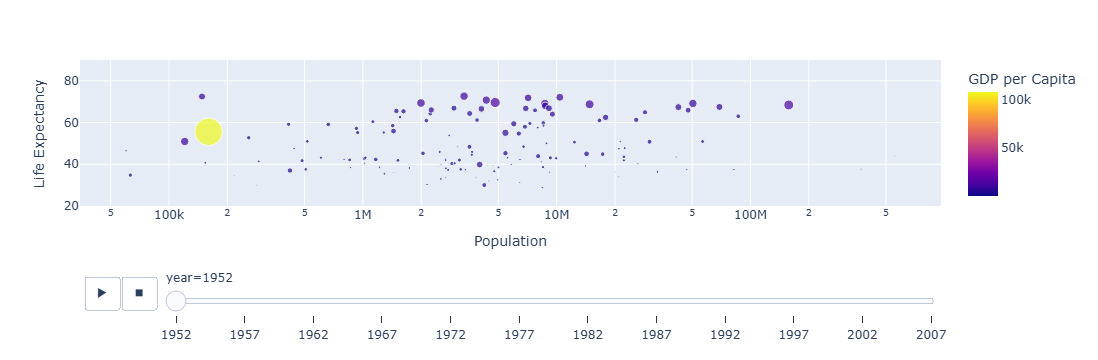

In [16]:
df = px.data.gapminder()
fig = px.scatter(df, x= "pop", y="lifeExp", log_x=True, hover_name="country",
           size="gdpPercap", color = "gdpPercap", labels = {"lifeExp": "Life Expectancy", "pop": "Population", "gdpPercap": "GDP per Capita"},
           animation_frame= "year", range_y = [20,90])

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1000
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 2000
#fig.layout.plot_bgcolor='#d7e8e8'
fig.show()